In [14]:
# ==============================
# 1. 库与数据读取
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_excel(r"C:\Users\GHS\Desktop\diabetic_data - 副本.xlsx")
X = df.drop("has_complication", axis=1)
y = df["has_complication"]

In [15]:
# ==============================
# 2. 数据集划分
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
# ==============================
# 3. 训练随机森林
# ==============================
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# 预测概率
rf_proba = rf.predict_proba(X_test)[:, 1]

In [17]:
# ==============================
# 4. 阈值固定 0.3 预测
# ==============================
threshold = 0.3
rf_pred = (rf_proba >= threshold).astype(int)

In [18]:
# ==============================
# 5. 模型评估
# ==============================
print("========= 随机森林（阈值0.3）结果 =========")
print(classification_report(y_test, rf_pred))
print(f"AUC：{roc_auc_score(y_test, rf_proba):.3f}")

========= 随机森林（阈值0.3）结果 =========
              precision    recall  f1-score   support

           0       0.84      0.80      0.82     16211
           1       0.33      0.39      0.36      4143

    accuracy                           0.71     20354
   macro avg       0.58      0.59      0.59     20354
weighted avg       0.73      0.71      0.72     20354

AUC：0.647


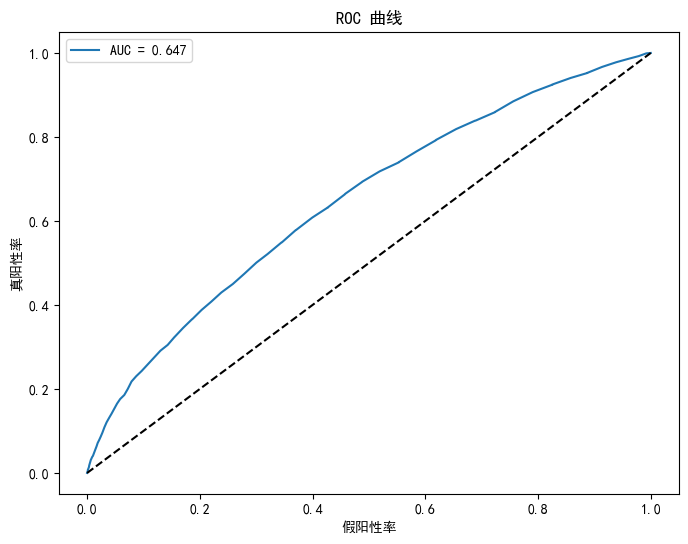

In [19]:
# ==============================
# 6. ROC 曲线
# ==============================
fpr, tpr, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, rf_proba):.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("假阳性率")
plt.ylabel("真阳性率")
plt.title("ROC 曲线")
plt.legend()
plt.show()

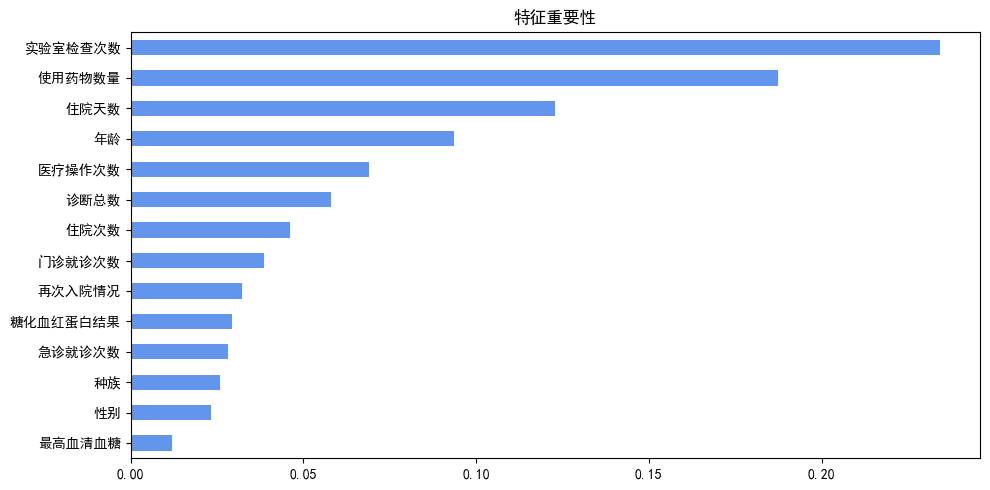

In [20]:
# ==============================
# 7. 特征重要性
# ==============================
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values()

plt.figure(figsize=(10, 5))
importances.plot(kind='barh', color='cornflowerblue')
plt.title("特征重要性")
plt.tight_layout()
plt.show()